# scintegration Package - Example Usage

This notebook demonstrates how to use the `scintegration` package to evaluate single-cell data integration quality.

**What is scintegration?**
- Measures how well batch effects are removed while preserving biological signal
- Compares embeddings from different integration methods
- Provides a unified integration score: (Biology Preserved - Batch Leaked) / (2 × (Biology + Batch))

**In this example:**
- Dataset: Bone marrow cells from Tabula Sapiens v2
- Model: Pretrained scVI (trained on 63M cells from Cell Census)
- Evaluation: Compare biology preservation vs. batch removal

## Step 1: Install and Import Required Packages

In [1]:
# Install scintegration package 
# !pip install scintegration

# Import required libraries
import numpy as np
import pandas as pd
from pathlib import Path
import os
import warnings
import anndata
warnings.simplefilter("ignore")

# Import scintegration components
from scintegration import (
    IntegrationScoreEvaluator,
    plot_metric_heatmap,
    plot_metric_bar_comparison,
    plot_metric_summary,
    configure_logging, 
    analyze_label_distribution
)

# Import dataset and model utilities
from czbenchmarks.datasets import load_dataset
from czbenchmarks.datasets.single_cell_labeled import SingleCellLabeledDataset
import scvi

## Step 1.1: Set Random Seed for Reproducibility

Setting random seeds ensures that results are reproducible across different runs.

In [2]:
import os, random, torch
from lightning.pytorch import seed_everything

SEED = 42

# Python, NumPy, PyTorch seeds
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# scVI + Lightning seeds
scvi.settings.seed = SEED
seed_everything(SEED, workers=True)

Seed set to 42
Seed set to 42


42

## Step 2: Load Dataset

We'll use the bone marrow dataset from Tabula Sapiens v2, which contains:
- ~8,000 cells from 3 donors
- 25 annotated cell types
- Multiple technical batches

In [3]:
# Load Immunobiology of Aging Cohort PBMC Profiling dataset from local .h5ad
dataset_path = Path("datasets") / "Immunobiology of Aging Cohort PBMC Profiling.h5ad"
if not dataset_path.exists():
    raise FileNotFoundError(f"Local dataset file not found: {dataset_path}")

adata = anndata.read_h5ad(dataset_path).copy()

# Extract labels
cell_type_labels = adata.obs['cell_type'].astype(str).values  # Biology we want to preserve
donor_labels = adata.obs['donor_id'].astype(str).values       # Batch effect we want to remove

print(f"Dataset loaded:")
print(f"Source: {dataset_path}")
print(f"Cells: {adata.shape[0]:,}")
print(f"Genes: {adata.shape[1]:,}")
print(f"Cell types: {len(np.unique(cell_type_labels))}")
print(f"Donors: {len(np.unique(donor_labels))}")

Dataset loaded:
Source: datasets\Immunobiology of Aging Cohort PBMC Profiling.h5ad
Cells: 9,354
Genes: 18,063
Cell types: 5
Donors: 234


## Step 2.1: Check Data Quality 

Before running expensive benchmarks, let's use the new utility functions to:
1. **Enable logging** (`configure_logging`) - See what's happening inside the tasks
2. **Analyze label distribution** (`analyze_label_distribution`) - Check for rare cell types that might cause issues

This helps catch problems early and understand your data better

In [4]:
# 1. Enable logging to see detailed messages
configure_logging('INFO')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'

# 2. Analyze cell type distribution
analysis = analyze_label_distribution(
    labels=cell_type_labels,
    min_samples=5,  # Flag cell types with < 5 cells (important for 5-fold CV)
    label_name="Cell Type"
)

# 3. Print summary
print(f"\nTotal cell types:    {analysis['n_classes']}")
print(f"Total cells:         {analysis['n_samples']:,}")
print(f"Smallest class size: {analysis['min_class_size']} cells")
print(f"Largest class size:  {analysis['max_class_size']:,} cells")
print(f"Imbalance ratio:     {analysis['imbalance_ratio']:.1f}x")

if analysis['has_rare_classes']:
    print(f"WARNING: {len(analysis['rare_classes'])} rare cell type(s) detected")
    print(f"These have < {5} samples and may cause issues in cross-validation.")
    print(f"Rare cell types:")
    for cell_type in analysis['rare_classes']:
        count = analysis['class_counts'][cell_type]
        print(f"• {cell_type}: {count} cells")
    print(f"TIP: Use min_class_size parameter in tasks to filter these automatically")
else:
    print(f"All cell types have ≥ {5} samples - good for 5-fold cross-validation")

2026-03-23 22:41:35,927 - scintegration - INFO - Logging configured for 'scintegration' package at INFO level
2026-03-23 22:41:35,935 - scintegration.utils - INFO - 
Cell Type Distribution Analysis:
2026-03-23 22:41:35,935 - scintegration.utils - INFO -   Total Cell Types: 5
2026-03-23 22:41:35,935 - scintegration.utils - INFO -   Total samples: 9354
2026-03-23 22:41:35,935 - scintegration.utils - INFO -   Class size range: [137, 5754]
2026-03-23 22:41:35,935 - scintegration.utils - INFO -   Imbalance ratio: 42.00x
2026-03-23 22:41:35,935 - scintegration.utils - INFO -   ✓ No rare classes detected (all have ≥ 5 samples)



Total cell types:    5
Total cells:         9,354
Smallest class size: 137 cells
Largest class size:  5,754 cells
Imbalance ratio:     42.0x
All cell types have ≥ 5 samples - good for 5-fold cross-validation


## Step 2.2: Create Batch Column for scVI

The pretrained scVI model expects a `batch` column in the dataset. We'll create this by combining dataset, assay, and donor information.

In [6]:
import functools

# Create batch column: combine cell_type and donor_id
# This matches the format expected by the pretrained scVI model
required_obs_keys = ["cell_type", "donor_id"]
adata.obs["batch"] = functools.reduce(
    lambda a, b: a + b, [adata.obs[c].astype(str) for c in required_obs_keys]
)

## Step 3: Load Pretrained scVI Model and Generate Embeddings

We'll use a pretrained scVI model (trained on 63M cells from CZ Cell Census) to generate embeddings.

**Note:** If you don't have the model yet, the cell below will automatically download it from the CZ Benchmarks S3 bucket. The model is approximately 500MB and may take a few minutes on first run.

In [7]:
# Configure path to your saved scVI model
# Change this path if your model is saved elsewhere
scvi_model_dir = Path("scvi_model_weights")  # Default location
# scvi_model_dir = Path("path/to/your/custom/scvi_model")  # Uncomment to use custom path

if not scvi_model_dir.exists() or not list(scvi_model_dir.iterdir()):
    print(f"scVI model not found at {scvi_model_dir}")
    import boto3
    from botocore import UNSIGNED
    from botocore.client import Config
    
    scvi_model_dir.mkdir(parents=True, exist_ok=True)
    print(f"   Created directory: {scvi_model_dir}")
    s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
    bucket_name = "cz-benchmarks-data"
    prefix = "models/v1/scvi_2023_12_15/homo_sapiens/"
    print("   Downloading model files from S3...")
    paginator = s3.get_paginator("list_objects_v2")
    file_count = 0
    for page in paginator.paginate(Bucket=bucket_name, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if not key.endswith("/"):
                local_path = scvi_model_dir / os.path.relpath(key, prefix)
                local_path.parent.mkdir(parents=True, exist_ok=True)
                s3.download_file(bucket_name, key, str(local_path))
                file_count += 1
    
    print(f"Downloaded {file_count} model files successfully")

# Prepare dataset for scVI (aligns gene names, etc.)
scvi.model.SCVI.prepare_query_anndata(adata, str(scvi_model_dir))

# Load the saved model
scvi_model = scvi.model.SCVI.load_query_data(adata, str(scvi_model_dir))
scvi_model.is_trained = True

# Generate embeddings using the loaded model
scvi_embeddings = scvi_model.get_latent_representation()

print(f"Embeddings generated: {scvi_embeddings.shape}")

INFO     File scvi_model_weights\model.pt already downloaded                                                       
INFO     Found 44.3125% reference vars in query data.                                                              
INFO     File scvi_model_weights\model.pt already downloaded                                                       
Embeddings generated: (9354, 50)


## Step 4: Evaluate Integration Quality with scintegration

Now we'll use the `scintegration` package to evaluate how well the scVI embeddings:
1. **Preserve biology** (cell types should cluster together)
2. **Remove batch effects** (donors should NOT cluster together)

The evaluator automatically computes all metrics and combines them into a single integration score.

### Four Core Metrics Used in Integration Score:

The integration score is computed from these 4 metrics (applied to both biology and batch):

1. **ARI (Adjusted Rand Index)** [0, 1] - Clustering agreement with labels
2. **NMI (Normalized Mutual Information)** [0, 1] - Information shared between clusters and labels
3. **Silhouette Score** [0, 1] - Cluster cohesion and separation
4. **F1 Score** [0, 1] - Classification performance (macro-averaged)

*Note: Additional metrics (Accuracy, AUROC, Precision, Recall) are computed for visualization but don't contribute to the integration score.*

### Integration Score Formula:
```
B = average(ARI_bio, NMI_bio, Silhouette_bio, F1_bio)
L = average(ARI_batch, NMI_batch, Silhouette_batch, F1_batch)

Integration Score = (B - L) / (2 × (B + L))
```

where B = Biology score and L = Leakage score

### Option 1: Run Evaluator with Default Parameters

In [8]:
# Create evaluator and calculate integration score
# This automatically computes all metrics (clustering, embedding, classification) for both biology preservation and batch removal
evaluator = IntegrationScoreEvaluator()
results = evaluator.evaluate_embeddings(
    embeddings=scvi_embeddings,
    obs=adata.obs,
    biology_labels=cell_type_labels,
    batch_labels=donor_labels,
    model_name='scvi'
)

print(results.summary())

2026-03-23 22:43:44,402 - scintegration.tasks - INFO - Starting ClusteringTask with 9354 cells, 50 features
2026-03-23 22:44:27,564 - scintegration.tasks - INFO - Leiden clustering identified 13 clusters
2026-03-23 22:44:27,604 - scintegration.tasks - INFO - Clustering metrics: ARI=0.2205, NMI=0.5599
2026-03-23 22:44:27,604 - scintegration.tasks - INFO - Starting EmbeddingTask with 9354 cells, 50 features
2026-03-23 22:44:29,181 - scintegration.tasks - INFO - Silhouette score: 0.4986
2026-03-23 22:44:29,181 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 9354 samples
2026-03-23 22:44:29,181 - scintegration.tasks - INFO - Total classes before filtering: 5
2026-03-23 22:44:29,181 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=10): 5
2026-03-23 22:44:29,181 - scintegration.tasks - INFO - Samples after filtering: 9354 / 9354 (100.0%)
2026-03-23 22:44:29,198 - scintegration.tasks - INFO - Found 5 classes, using 'macro' averaging for met

INTEGRATION SCORE RESULTS

#1 SCVI:
  Integration Score: +0.2503
  Biology (B):       0.7237
  Leakage (L):       0.2409
    Biology metrics: ARI=0.610, NMI=0.560, Sil=0.749, F1=0.975
    Batch metrics:   ARI=0.509, NMI=0.143, Sil=0.277, F1=0.035

BEST MODEL: SCVI (IS = +0.2503)


In [9]:
# Compare integrated embedding vs non-integrated baseline embedding
import scipy.sparse as sp
from sklearn.decomposition import PCA

# Use same latent dimensionality as scVI for fair comparison
n_components = scvi_embeddings.shape[1]
X_raw = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)

pca_baseline_embeddings = PCA(n_components=n_components, random_state=42).fit_transform(X_raw)

comparison_results = evaluator.evaluate_embeddings_with_baseline(
    embeddings_by_model={
        'scvi': {
            'with_integration': scvi_embeddings,
            'without_integration': pca_baseline_embeddings,
        }
    },
    obs=adata.obs,
    biology_labels=cell_type_labels,
    batch_labels=donor_labels,
    classification_min_class_size=10
    # You can omit 'without_integration' and pass raw_features for automatic PCA fallback
    # raw_features=X_raw,
    # use_pca_baseline_when_missing=True,
    # pca_n_components=n_components,
 )

print(comparison_results.summary())
comparison_df = comparison_results.to_dataframe()
comparison_df

2026-03-23 22:51:41,765 - scintegration.tasks - INFO - Starting ClusteringTask with 9354 cells, 50 features
2026-03-23 22:51:45,298 - scintegration.tasks - INFO - Leiden clustering identified 13 clusters
2026-03-23 22:51:45,339 - scintegration.tasks - INFO - Clustering metrics: ARI=0.2205, NMI=0.5599
2026-03-23 22:51:45,342 - scintegration.tasks - INFO - Starting EmbeddingTask with 9354 cells, 50 features
2026-03-23 22:51:47,018 - scintegration.tasks - INFO - Silhouette score: 0.4986
2026-03-23 22:51:47,018 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 9354 samples
2026-03-23 22:51:47,036 - scintegration.tasks - INFO - Total classes before filtering: 5
2026-03-23 22:51:47,036 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=10): 5
2026-03-23 22:51:47,036 - scintegration.tasks - INFO - Samples after filtering: 9354 / 9354 (100.0%)
2026-03-23 22:51:47,044 - scintegration.tasks - INFO - Found 5 classes, using 'macro' averaging for met

INTEGRATED VS BASELINE COMPARISON

#1 SCVI (provided baseline):
  IS with/without: +0.2503 / +0.2334
  ΔIS: +0.0169
  ΔB:  -0.0133
  ΔL:  -0.0271

TOP IMPROVEMENT: SCVI (ΔIS = +0.0169)


,model_name,baseline_source,with_integration_score,without_integration_score,with_integration_B,without_integration_B,with_integration_L,without_integration_L,delta_integration_score,delta_B,delta_L
0,scvi,provided,0.250269,0.233365,0.723668,0.736943,0.240877,0.267936,0.016904,-0.013275,-0.027059


With vs Without summary:
INTEGRATION SCORE RESULTS

#1 SCVI (INTEGRATED):
  Integration Score: +0.2503
  Biology (B):       0.7237
  Leakage (L):       0.2409
    Biology metrics: ARI=0.610, NMI=0.560, Sil=0.749, F1=0.975
    Batch metrics:   ARI=0.509, NMI=0.143, Sil=0.277, F1=0.035

#2 SCVI (BASELINE):
  Integration Score: +0.2334
  Biology (B):       0.7369
  Leakage (L):       0.2679
    Biology metrics: ARI=0.636, NMI=0.612, Sil=0.706, F1=0.994
    Batch metrics:   ARI=0.512, NMI=0.157, Sil=0.346, F1=0.057

BEST MODEL: SCVI (INTEGRATED) (IS = +0.2503)


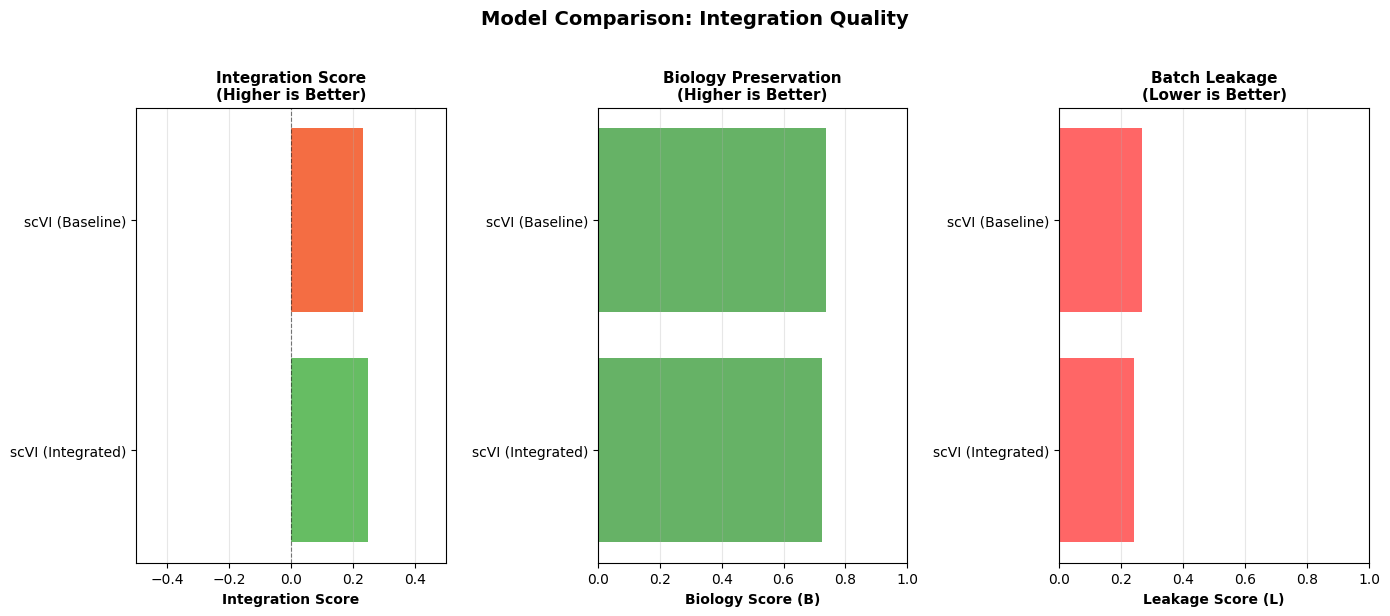

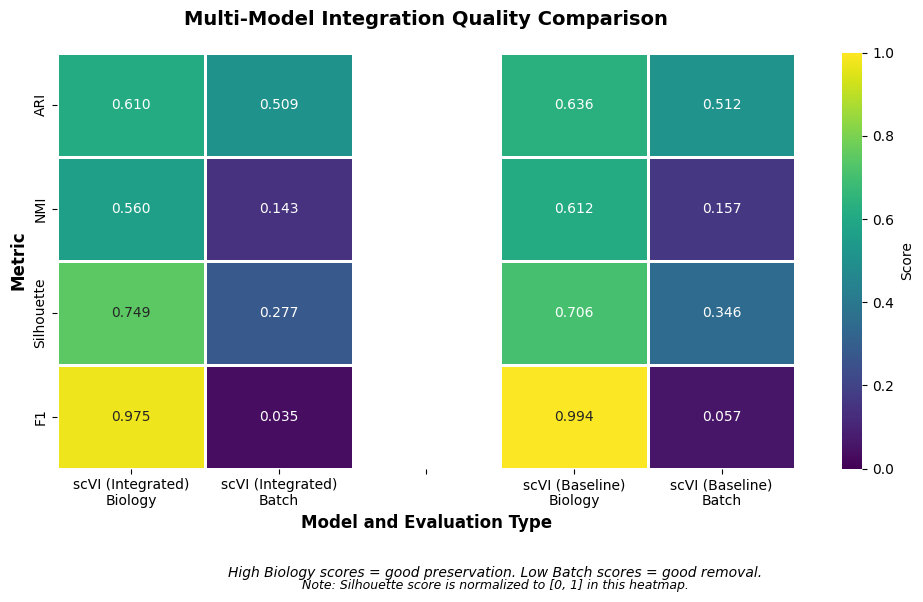

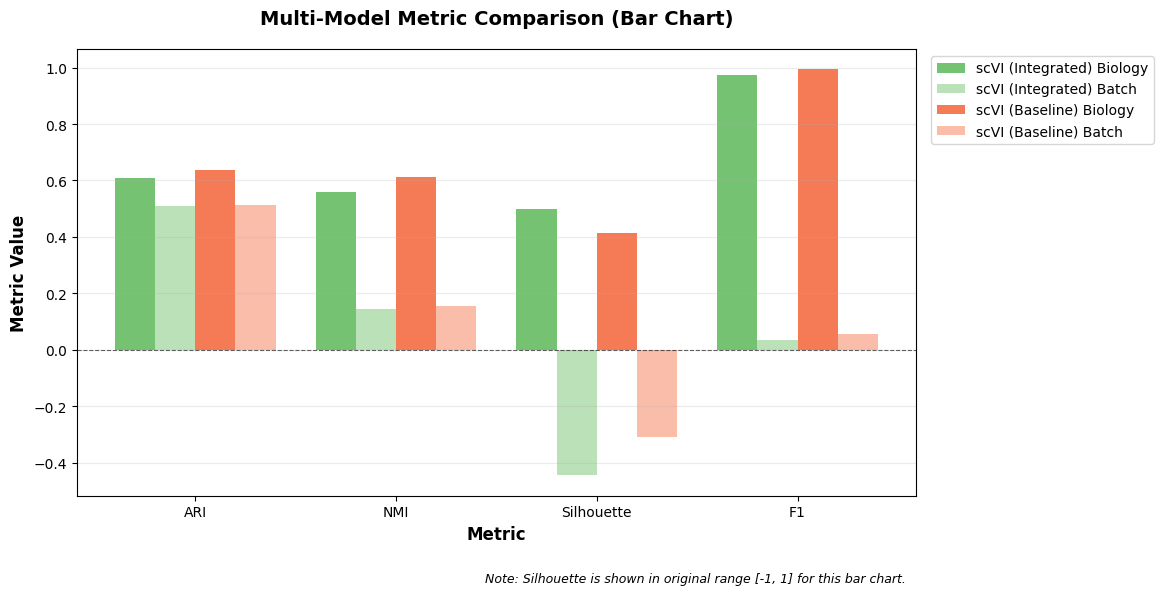

In [10]:
# Build a two-condition result object for built-in plotting
from scintegration.evaluator import IntegrationScoreResults
from scintegration import plot_model_comparison, plot_metric_heatmap, plot_metric_bar_comparison
from IPython.display import display

scvi_cmp = comparison_results.comparisons['scvi']
paired_results = IntegrationScoreResults({
    'scVI (Integrated)': scvi_cmp.with_integration,
    'scVI (Baseline)': scvi_cmp.without_integration,
})

print("With vs Without summary:")
print(paired_results.summary())

# Visual 1: Integration/Biology/Leakage comparison
# Increased figsize for better spacing
display(plot_model_comparison(paired_results, figsize=(14, 6)))

# Visual 2: Core metric heatmap
display(plot_metric_heatmap(
    paired_results,
    model_names=['scVI (Integrated)', 'scVI (Baseline)'],
    figsize=(10, 6)
))

# Visual 3: Core metric bars
display(plot_metric_bar_comparison(
    paired_results,
    model_names=['scVI (Integrated)', 'scVI (Baseline)'],
    figsize=(14, 6)
))

### Option 1.6: Visualize With vs Without Integration

Use the existing `scintegration` visualization functions by building a temporary two-model result object:
- `scvi_with_integration`
- `scvi_without_integration`

Then plot score-level and metric-level comparisons.

### Option 1.5: Compare With vs Without Integration (New Baseline API)

This runs the new paired evaluator API using:
- **with_integration**: scVI latent embedding
- **without_integration**: PCA embedding from the same data (baseline)

This gives a direct delta comparison (`ΔIS`, `ΔB`, `ΔL`).

### Option 2: Custom Parameters with Evaluator

You can  pass custom parameters directly to `evaluate_embeddings()`. This gives you control over both classification and clustering settings while still using the convenient evaluator API:

**Classification Parameters:**
- `classification_n_folds`: Number of CV folds (default: 5)
- `classification_min_class_size`: Minimum samples per class (default: 10)

**Clustering Parameters:**
- `clustering_n_neighbors`: Number of neighbors for k-NN graph (default: 15)
- `clustering_resolution`: Leiden resolution parameter (default: 1.0)

This is ideal when you:
- Want to include rare cell types (reduce `min_class_size`)
- Need more/fewer clusters (adjust `resolution`)
- Want smoother clusters (increase `n_neighbors`)
- Still want the full evaluator workflow with all metrics + visualization support

In [11]:
# Example: Custom parameters for datasets with rare cell types
# These parameters affect both biology and batch classification tasks
evaluator_custom = IntegrationScoreEvaluator()
results_custom = evaluator_custom.evaluate_embeddings(
    embeddings=scvi_embeddings,
    obs=adata.obs,
    biology_labels=cell_type_labels,
    batch_labels=donor_labels,
    model_name='scvi',
    classification_min_class_size=5   # Lower threshold = include rare cell types
)

print(results_custom.summary())

2026-03-23 23:05:07,946 - scintegration.tasks - INFO - Starting ClusteringTask with 9354 cells, 50 features
2026-03-23 23:05:11,425 - scintegration.tasks - INFO - Leiden clustering identified 13 clusters
2026-03-23 23:05:11,467 - scintegration.tasks - INFO - Clustering metrics: ARI=0.2205, NMI=0.5599
2026-03-23 23:05:11,474 - scintegration.tasks - INFO - Starting EmbeddingTask with 9354 cells, 50 features
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Silhouette score: 0.4986
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 9354 samples
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Total classes before filtering: 5
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=5): 5
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Samples after filtering: 9354 / 9354 (100.0%)
2026-03-23 23:05:13,305 - scintegration.tasks - INFO - Found 5 classes, using 'macro' averaging for metr

INTEGRATION SCORE RESULTS

#1 SCVI:
  Integration Score: +0.2510
  Biology (B):       0.7237
  Leakage (L):       0.2399
    Biology metrics: ARI=0.610, NMI=0.560, Sil=0.749, F1=0.975
    Batch metrics:   ARI=0.509, NMI=0.143, Sil=0.277, F1=0.031

BEST MODEL: SCVI (IS = +0.2510)


### Option 3: Running Tasks Separately (Maximum Control)

If you need maximum flexibility beyond what the evaluator provides, you can run tasks individually. This is useful when:
- You want to run only specific tasks (e.g., classification without clustering)
- You need different parameters for biology vs batch tasks (e.g., different resolution for each)
- Building custom evaluation pipelines with non-standard workflows

**Note:** Running tasks separately means you won't get an `IntegrationScoreResults` object, so you'll need to handle visualization separately.

Below we demonstrate running classification and clustering tasks with custom parameters:

In [12]:
# Running custom tasks with full control over each task separately
from scintegration import (
    MetadataLabelPredictionTask, MetadataLabelPredictionTaskInput,
    ClusteringTask, ClusteringTaskInput
)

# Example 1: Custom classification task
custom_classification_input = MetadataLabelPredictionTaskInput(
    labels=cell_type_labels,
    n_folds=10,           # 10-fold cross-validation
    min_class_size=10,    # Filter classes with < 10 samples
)
classification_task = MetadataLabelPredictionTask()
classification_results = classification_task.run(scvi_embeddings, custom_classification_input)
print(f"Got {len(classification_results)} classification metrics")
for result in classification_results[:3]:
    print(f"  • {result.metric_type.name} = {result.value:.4f}")

# Example 2: Custom clustering task
custom_clustering_input = ClusteringTaskInput(obs=adata.obs, input_labels=cell_type_labels)
clustering_task = ClusteringTask(
    n_neighbors=25,      # CUSTOM: More neighbors for smoother clusters
    resolution=0.5       # CUSTOM: Lower resolution for coarser clustering
)
clustering_results = clustering_task.run(scvi_embeddings, custom_clustering_input)
print(f"Got {len(clustering_results)} clustering metrics")
for result in clustering_results:
    print(f"  • {result.metric_type.name} = {result.value:.4f}")

2026-03-23 23:13:54,113 - scintegration.tasks - INFO - Starting MetadataLabelPredictionTask with 9354 samples
2026-03-23 23:13:54,117 - scintegration.tasks - INFO - Total classes before filtering: 5
2026-03-23 23:13:54,118 - scintegration.tasks - INFO - Total classes after filtering (min_class_size=10): 5
2026-03-23 23:13:54,121 - scintegration.tasks - INFO - Samples after filtering: 9354 / 9354 (100.0%)
2026-03-23 23:13:54,129 - scintegration.tasks - INFO - Found 5 classes, using 'macro' averaging for metrics
2026-03-23 23:13:54,130 - scintegration.tasks - INFO - Using 10-fold stratified cross-validation with random_seed=42
2026-03-23 23:13:54,132 - scintegration.tasks - INFO - Created classifiers: ['lr', 'knn', 'rf']
2026-03-23 23:13:54,133 - scintegration.tasks - INFO - Running cross-validation for lr...
2026-03-23 23:13:57,133 - scintegration.tasks - INFO - Running cross-validation for knn...
2026-03-23 23:13:57,534 - scintegration.tasks - INFO - Running cross-validation for rf...


Got 20 classification metrics
  • MEAN_FOLD_F1_SCORE = 0.9769
  • MEAN_FOLD_ACCURACY = 0.9928
  • MEAN_FOLD_PRECISION = 0.9803


2026-03-23 23:14:30,874 - scintegration.tasks - INFO - Leiden clustering identified 8 clusters
2026-03-23 23:14:30,912 - scintegration.tasks - INFO - Clustering metrics: ARI=0.3927, NMI=0.6662


Got 2 clustering metrics
  • ADJUSTED_RAND_INDEX = 0.3927
  • NORMALIZED_MUTUAL_INFO = 0.6662


## Step 5: Visualize Results

The scintegration package provides built-in visualization functions:

1. **`plot_metric_heatmap()`** - Biology vs Batch breakdown for each metric
2. **`plot_metric_bar_comparison()`** - Bar-chart version of metric comparison (Silhouette shown in original range [-1, 1])
3. **`plot_model_comparison()`** - Compare Integration Score, Biology Score, and Leakage Score across models
4. **`plot_metric_summary()`** - Combined view with model ranking and detailed metric breakdown

*Note: In `plot_metric_heatmap()`, Silhouette is normalized to [0, 1].*

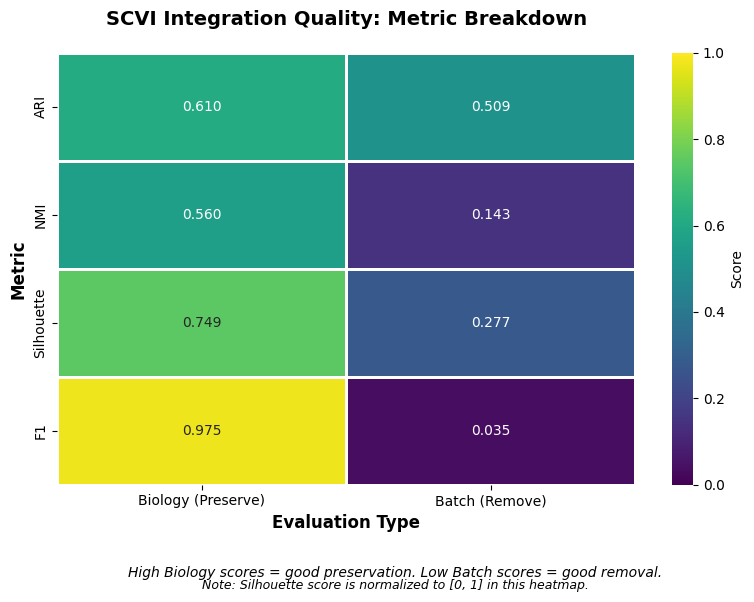

In [13]:
# 1. Metric Heatmap - Shows Biology vs Batch for each of the 4 core metrics
plot_metric_heatmap(results, model_names='scvi')

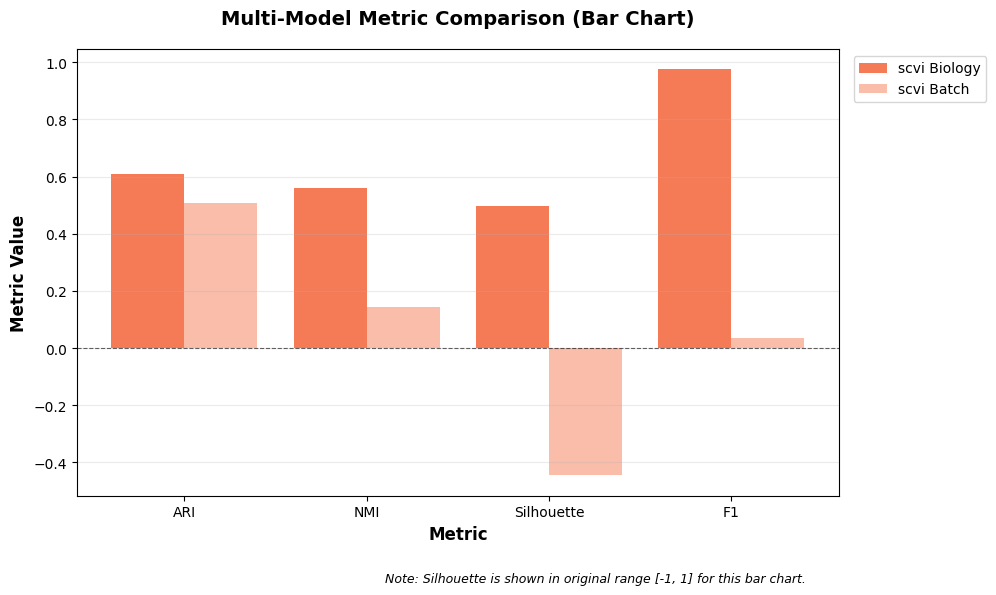

In [14]:
# 2. Metric Bar Comparison - Similar to heatmap, but with bars
# Note: Silhouette is shown here in original range [-1, 1]
plot_metric_bar_comparison(results, model_names='scvi')

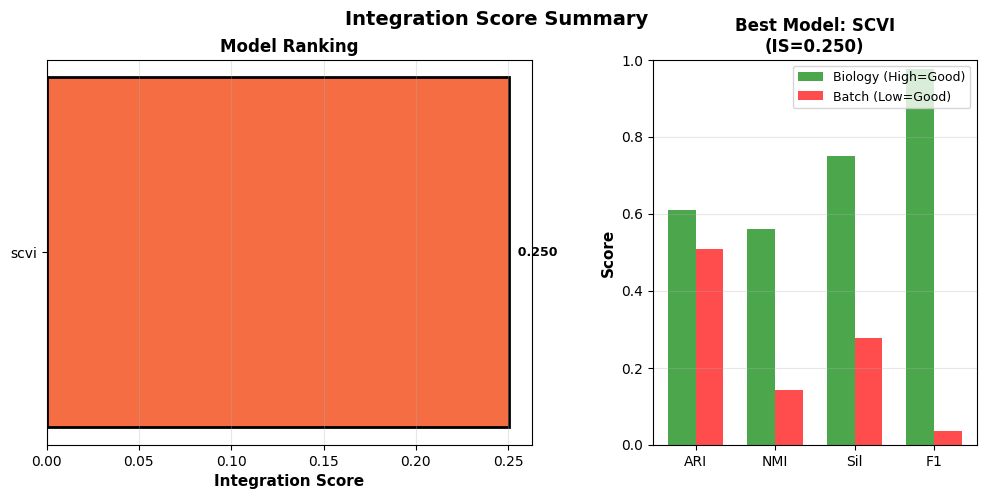

In [15]:
# 3. Metric Summary - Combined view with ranking and detailed breakdown
plot_metric_summary(results)

## Step 6: Export Metrics to CSV

The scintegration package provides a convenient method to export all calculated metrics to a CSV file. This includes:
- Integration Score, Biology Score (B), and Leakage Score (L)
- All core metrics: ARI, NMI, Silhouette, F1 (for both biology and batch)
- Additional classification metrics: Accuracy, Precision, Recall, AUROC 

The exported file is automatically named with the date and time for easy tracking of experiments.

In [16]:
# Export metrics to CSV file
# The file will be named: integration_metrics_{model_name}_YYYY-MM-DD.csv

csv_path = results.to_csv(output_dir=".")

print(f"Metrics exported successfully!")
print(f"File saved to: {csv_path}")

# You can also view the data as a DataFrame before exporting
df = results.to_dataframe()
print(f"\nDataFrame preview:")
print(df)

2026-03-23 23:17:59,956 - scintegration.utils - INFO - Metrics exported to: integration_metrics_all_models_2026-03-23.csv


Metrics exported successfully!
File saved to: integration_metrics_all_models_2026-03-23.csv

DataFrame preview:
  model_name  integration_score         B         L   bio_ari   bio_nmi  \
0       scvi           0.250269  0.723668  0.240877  0.610227  0.559932   

   bio_silhouette    bio_f1  bio_accuracy  bio_precision  bio_recall  \
0         0.74932  0.975193      0.992303       0.982713    0.968624   

   bio_auroc  batch_ari  batch_nmi  batch_silhouette  batch_f1  \
0        NaN    0.50851   0.142805          0.277152   0.03504   

   batch_accuracy  batch_precision  batch_recall  batch_auroc  
0        0.110461         0.038249      0.040637          NaN  


## Summary

This notebook demonstrated:
1. Loading a single-cell dataset
2. Generating embeddings with pretrained scVI
3. Using `scintegration` to evaluate integration quality with one simple method call
4. Visualizing results with three different plot types

### Key Takeaways:
- **Simple API**: One call to `evaluate_embeddings()` runs all metrics automatically
- **Comprehensive Metrics**: ARI, NMI, Silhouette, F1 for both biology and batch
- **Flexible Visualization**: Three plot types for different analysis needs

### Next Steps:
- Try with your own datasets and models
- Compare multiple integration methods
- Adjust integration parameters based on scores
- Use the results to select the best integration approach for your data

### Installation:
```bash
pip install scintegration
```

### Documentation:
See the `single-cell-integration-score/` directory for full API documentation.